In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, log_loss, accuracy_score, PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV

from src.common.load_data import load_data, drop_targets, get_test_val_sets
from src.common.treat_missing import TabularPreprocessor, PreprocessConfig
from src.common.evaluations import evaluate_classification
from src.utils.plots import plot_loss_curve

import warnings

**Understanding the Approved_Flag Tiers (P1 to P4)**

The dataset segments the risk ranking from lowest default risk to highest default risk into four classes:

🟢 **P1 (Premium / Best Customers)**: These are excellent, lowest-risk customers. They possess top-tier CIBIL credit footprints, exceptional repayment histories, and are automatically fast-tracked for unconditional approval.

🟡 **P2 (Good Customers)**: These are highly reliable, low-risk customers. They satisfy the core banking lending criteria safely and are standard "Approved" applicants. (Note: In this specific Kaggle dataset, P2 typically represents the largest share/majority class of accepted loans).

🟠 **P3 (Marginal / Conditional Customers)**: These are medium-risk customers. They generally trigger a "Conditional Approval" or require manual underwriting adjustments (e.g., lower loan amount, higher interest rate, or extra collateral).

🔴 **P4 (Bad / High-Risk Customers)**: These are high-risk customers. They have poor credit histories or high indicators of delinquency and are categorized under "Refer" or "Reject" status.

In [ ]:
pd.options.display.max_rows = 200

In [ ]:
warnings.filterwarnings("ignore")

In [7]:
df = load_data("./data/cibil_score/cibil_score.csv")
X, y_lin_reg, y_binary, y_multiclass = drop_targets(df)
X_train, X_val,  X_test, y_train, y_val, y_test = get_test_val_sets(X, y_binary, test_size=0.3)

0


## Replace Missing Values

In [8]:
high_missing = [
    "cc_utilization",
    "pl_utilization"
]
median_columns = [
    "age_oldest_tl",
    "age_newest_tl",
    "pct_currentbal_all_tl",
    "time_since_recent_payment"
]
"""
Delinquency:
Features like num_times_30p_dpd or delinq_2yrs count how many 
separate instances a person crossed that late-payment threshold 
over a specific timeframe (such as the past 6 months, 12 months, or 2 years).
"""
delinquency_columns = [
    "max_delinquency_level",
    "max_deliq_6mts",
    "max_deliq_12mts",
    "time_since_recent_deliquency",
    "time_since_first_deliquency"
]

# If there is no entry means no enquiry
enquiry_columns = [
    "tot_enq",
    "cc_enq",
    "pl_enq",
    "cc_enq_l6m",
    "cc_enq_l12m",
    "pl_enq_l6m",
    "pl_enq_l12m",
    "enq_l3m",
    "enq_l6m",
    "enq_l12m"
]

# Maximum unsecured exposure = 0%
# Customer with no unsecured loan
max_unsecur = ["max_unsec_exposure_inpct"]

zero_cols = max_unsecur + enquiry_columns + delinquency_columns

log_transform_cols = ["netmonthlyincome"]

In [9]:
config = PreprocessConfig(
        high_missing=high_missing,
        median_cols=median_columns,
        zero_cols=zero_cols,
        log_transform_cols=log_transform_cols,
    )

In [10]:
preprocessor = TabularPreprocessor(config)
X_train_processed, X_val_processed, X_test_processed = preprocessor.fit_transform(
    X_train, X_val, X_test
)

2026-08-31 05:24:13,662 [INFO] src.common.treat_missing: Fitted median for 'age_oldest_tl' = 33.0
2026-08-31 05:24:13,668 [INFO] src.common.treat_missing: Fitted median for 'age_newest_tl' = 8.0
2026-08-31 05:24:13,672 [INFO] src.common.treat_missing: Fitted median for 'pct_currentbal_all_tl' = 0.623
2026-08-31 05:24:13,676 [INFO] src.common.treat_missing: Fitted median for 'time_since_recent_payment' = 74.0


2026-08-31 05:24:13,785 [INFO] src.common.treat_missing: Fitted no-enquiry fill value for 'time_since_recent_enq' = 4769
2026-08-31 05:24:14,014 [INFO] src.common.treat_missing: Fitted ColumnTransformer on 79 numeric and 5 categorical columns.
2026-08-31 05:24:14,015 [INFO] src.common.treat_missing: TabularPreprocessor fit complete.
2026-08-31 05:24:14,245 [INFO] src.common.treat_missing: Data processing complete! Ready for model training.


In [11]:
model = LogisticRegression(max_iter=500, solver="lbfgs",
        random_state=42)
model.fit(X_train_processed, y_train)
y_pred = model.predict(X_val_processed)
y_prob = model.predict_proba(X_val_processed)[:,1]

In [12]:
evaluate_classification(model, X_val_processed, y_val, binary=True)

              precision    recall  f1-score   support

           0       0.84      0.73      0.78      2030
           1       0.91      0.95      0.93      5670

    accuracy                           0.89      7700
   macro avg       0.87      0.84      0.86      7700
weighted avg       0.89      0.89      0.89      7700



{'accuracy': 0.8924675324675325,
 'f1_macro': 0.8551577262298371,
 'precision_macro': 0.8744013527602097,
 'recall_macro': 0.8403332725171806,
 'precision_weighted': 0.890148693309696,
 'recall_weighted': 0.8924675324675325,
 'f1_weighted': 0.8899089275361858,
 'confusion_matrix': array([[1482,  548],
        [ 280, 5390]]),
 'roc_auc': 0.9317456842251588}

In [13]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# Compute AUC
auc = roc_auc_score(y_val, y_prob)

print("AUC =", auc)

AUC = 0.9317456842251588


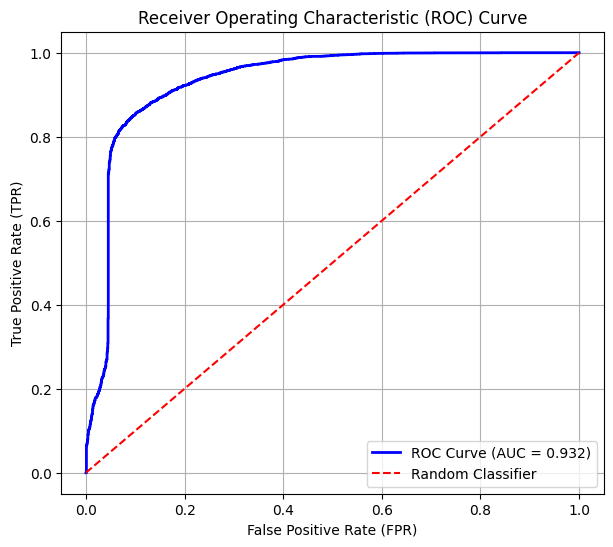

In [14]:
plt.figure(figsize=(7,6))

# ROC Curve
plt.plot(fpr, tpr,
         color='blue',
         linewidth=2,
         label=f'ROC Curve (AUC = {auc:.3f})')

# Random Guess Line
plt.plot([0,1], [0,1],
         linestyle='--',
         color='red',
         label='Random Classifier')

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

/home/neeraj/Projects/ml_course/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/neeraj/Projects/ml_course/ml_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

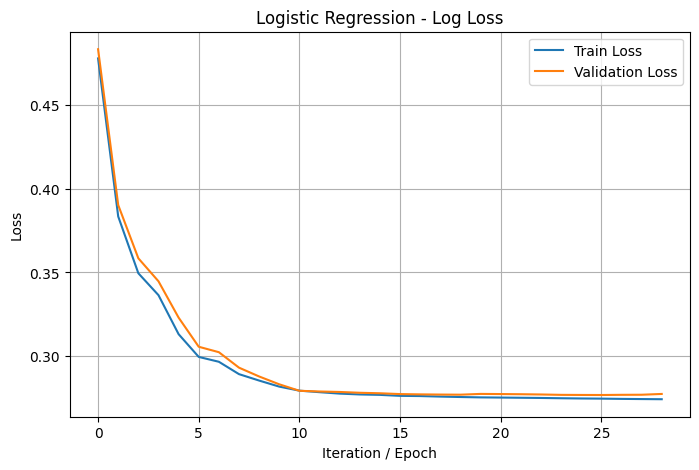

In [15]:
train_loss = []
val_loss = []
train_accuracy = []
val_accuracy = []

for i in range(1, 30):

    model = LogisticRegression(
        max_iter=i,
        solver="lbfgs",
        random_state=42
    )

    model.fit(X_train_processed, y_train)

    train_prob = model.predict_proba(X_train_processed)
    val_prob = model.predict_proba(X_val_processed)
    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)

    train_loss.append(
        log_loss(y_train, train_prob)
    )

    val_loss.append(
        log_loss(y_val, val_prob)
    )

    train_accuracy.append(
        accuracy_score(y_train, train_pred)
    )

    val_accuracy.append(
        accuracy_score(y_val, val_pred)
    )


plot_loss_curve(
    train_loss,
    val_loss,
    "Logistic Regression - Log Loss"
)

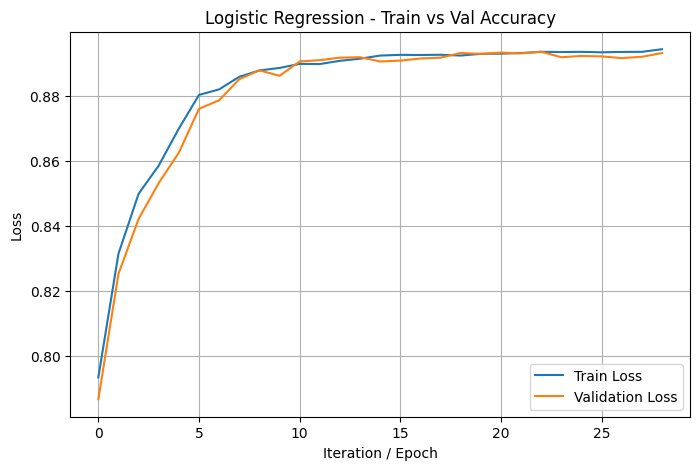

In [16]:
plot_loss_curve(
    train_accuracy,
    val_accuracy,
    "Logistic Regression - Train vs Val Accuracy"
)

## Logistic Regression Parameters

**C** : Inverse of regularization strength; must be a positive float. Like in support vector machines, smaller values specify stronger regularization. *default=1.0*

**C=np.inf results in unpenalized logistic regression.**

**penalty : {'l1', 'l2', 'elasticnet', None}, default='l2'**
Specify the norm of the penalty:

None: no penalty is added;
'l2': add an L2 penalty term and it is the default choice;
'l1': add an L1 penalty term;
'elasticnet': both L1 and L2 penalty terms are added.

**l1_ratio : float, default=0.0**
The Elastic-Net mixing parameter, with 0 <= l1_ratio <= 1. Setting l1_ratio=1 gives a pure L1-penalty, setting l1_ratio=0 a pure L2-penalty. Any value between 0 and 1 gives an Elastic-Net penalty of the form l1_ratio * L1 + (1 - l1_ratio) * L2

**class_weight : dict or 'balanced', default=None**
Weights associated with classes in the form {class_label: weight}. If not given, all classes are supposed to have weight one.

The "balanced" mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y)).

Note that these weights will be multiplied with sample_weight (passed through the fit method) if sample_weight is specified.

The choice of the algorithm depends on the penalty chosen (l1_ratio=0 for L2-penalty, l1_ratio=1 for L1-penalty and 0 < l1_ratio < 1 for Elastic-Net) and on (multinomial) multiclass support:

**solver : {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'**
Algorithm to use in the optimization problem. Default is 'lbfgs'.

**Solver and l1_ration support:**

solver	l1_ratio	multinomial multiclass

'lbfgs'	l1_ratio=0	yes

'liblinear'	l1_ratio=1 or l1_ratio=0	no

'newton-cg'	l1_ratio=0	yes

'newton-cholesky'	l1_ratio=0	yes

'sag'	l1_ratio=0	yes

'saga'	0<=l1_ratio<=1	yes


## Regularization

### Ridge regression

penalty = 'l2'

solver = 'saga' or 'lbfgs' both giving same accuracy

l1_ratio = 0

C = 1.0 and 100.0 giving same accuracy

In [ ]:
model = LogisticRegression(C=100.0, penalty='l2', max_iter=500, solver='saga')
model.fit(X_train_processed, y_train)     

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100.0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the for

In [ ]:
evaluate_classification(model, X_val_processed, y_val, binary=True)

              precision    recall  f1-score   support

           0       0.84      0.73      0.78      2030
           1       0.91      0.95      0.93      5670

    accuracy                           0.89      7700
   macro avg       0.87      0.84      0.85      7700
weighted avg       0.89      0.89      0.89      7700



{'accuracy': 0.8923376623376623,
 'f1_macro': 0.8549570380124445,
 'precision_macro': 0.8742798137299532,
 'recall_macro': 0.8400869670984614,
 'precision_weighted': 0.8900123577539027,
 'recall_weighted': 0.8923376623376623,
 'f1_weighted': 0.8897652939714604,
 'confusion_matrix': array([[1481,  549],
        [ 280, 5390]]),
 'roc_auc': 0.9313205793172953}

### Lasso regression

penalty = 'l1'

solver = 'saga' only 'saga' support 'l1'

l1_ratio = 1

C = 1.0 and 100.0 giving same accuracy

In [ ]:
lasso_model = LogisticRegression(C=1.0, penalty='l1', max_iter=500, solver='saga')
lasso_model.fit(X_train_processed, y_train)  
evaluate_classification(lasso_model, X_val_processed, y_val, binary=True)

              precision    recall  f1-score   support

           0       0.84      0.73      0.78      2030
           1       0.91      0.95      0.93      5670

    accuracy                           0.89      7700
   macro avg       0.87      0.84      0.85      7700
weighted avg       0.89      0.89      0.89      7700



{'accuracy': 0.8923376623376623,
 'f1_macro': 0.8549054748935647,
 'precision_macro': 0.8744050722764758,
 'recall_macro': 0.8399288451012589,
 'precision_weighted': 0.8900135437787997,
 'recall_weighted': 0.8923376623376623,
 'f1_weighted': 0.8897439208911396,
 'confusion_matrix': array([[1480,  550],
        [ 279, 5391]]),
 'roc_auc': 0.9313159746657284}

### Elasticnet regression

penalty = 'elasticnet'

solver = 'saga' only 'saga' support 'elasticnet'

l1_ratio = 0.7

C = 1.0 and 100.0 giving same accuracy

In [ ]:
model = LogisticRegression(C=1.0, penalty='elasticnet', l1_ratio=0.7, max_iter=500, solver='saga')
model.fit(X_train_processed, y_train)  
evaluate_classification(model, X_val_processed, y_val, binary=True)

              precision    recall  f1-score   support

           0       0.84      0.73      0.78      2030
           1       0.91      0.95      0.93      5670

    accuracy                           0.89      7700
   macro avg       0.87      0.84      0.86      7700
weighted avg       0.89      0.89      0.89      7700



{'accuracy': 0.8924675324675325,
 'f1_macro': 0.8551062567752756,
 'precision_macro': 0.8745265151515151,
 'recall_macro': 0.8401751505199782,
 'precision_weighted': 0.8901497933884298,
 'recall_weighted': 0.8924675324675325,
 'f1_weighted': 0.8898875978289368,
 'confusion_matrix': array([[1481,  549],
        [ 279, 5391]]),
 'roc_auc': 0.9313107618526338}

## Grid Search for best parameters
As logistic regression does not have more parameters to search try GridSearch.

In [14]:
# Different penalties only work with certain solvers (see the parameter
# notes above), so we search each penalty family separately instead of
# one grid with invalid solver/penalty combinations.
param_grid = [
    {"penalty": ["l2"], "solver": ["lbfgs"],
     "C": [0.01, 0.1, 1, 10, 100], "max_iter": [200]},
    {"penalty": ["l1"], "solver": ["saga"],
     "C": [0.01, 0.1, 1, 10, 100], "max_iter": [200]},
    {"penalty": ["elasticnet"], "solver": ["saga"],
     "C": [0.01, 0.1, 1, 10, 100], "l1_ratio": [0.3, 0.5, 0.7],
     "max_iter": [200]},
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1,
    error_score="raise",
)

try:
    grid_search.fit(X_train_processed, y_train)
except Exception as exc:
    raise RuntimeError(f"GridSearchCV failed: {exc}") from exc

print("Best parameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")
cv_results[["params", "mean_test_score", "std_test_score", "rank_test_score"]].head(10)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best parameters: {'C': 100, 'max_iter': 200, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.9304


,params,mean_test_score,std_test_score,rank_test_score
4,"{'C': 100, 'max_iter': 200, 'penalty': 'l2', '...",0.930388,0.002946,1
3,"{'C': 10, 'max_iter': 200, 'penalty': 'l2', 's...",0.930373,0.002961,2
2,"{'C': 1, 'max_iter': 200, 'penalty': 'l2', 'so...",0.930344,0.002955,3
1,"{'C': 0.1, 'max_iter': 200, 'penalty': 'l2', '...",0.930099,0.002920,4
6,"{'C': 0.1, 'max_iter': 200, 'penalty': 'l1', '...",0.928505,0.002832,5
15,"{'C': 0.1, 'l1_ratio': 0.7, 'max_iter': 200, '...",0.928478,0.002832,6
7,"{'C': 1, 'max_iter': 200, 'penalty': 'l1', 'so...",0.928465,0.002848,7
18,"{'C': 1, 'l1_ratio': 0.7, 'max_iter': 200, 'pe...",0.928459,0.002847,8
17,"{'C': 1, 'l1_ratio': 0.5, 'max_iter': 200, 'pe...",0.928455,0.002847,9
8,"{'C': 10, 'max_iter': 200, 'penalty': 'l1', 's...",0.928453,0.002847,10


## Run Logistic Regression with best parameters
- Logistic regression with best parameters
- Run evaluation
- Plot train-validation loss, precison-recall, roc-auc, train-val accuracy

Using best parameters from grid search: {'C': 100, 'max_iter': 200, 'penalty': 'l2', 'solver': 'lbfgs'}


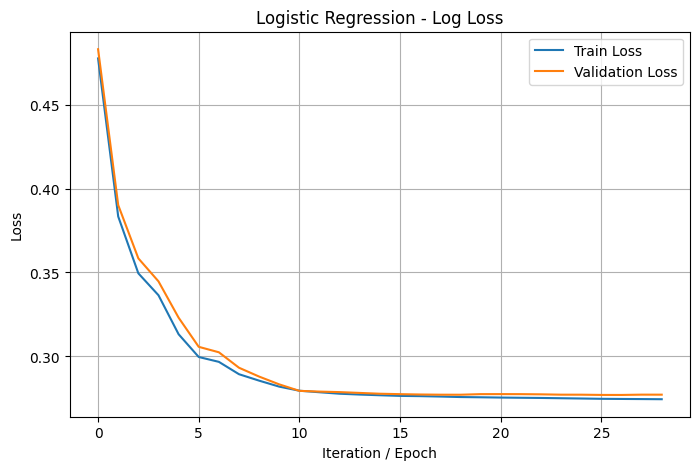

              precision    recall  f1-score   support

           0       0.84      0.73      0.78      2030
           1       0.91      0.95      0.93      5670

    accuracy                           0.89      7700
   macro avg       0.87      0.84      0.86      7700
weighted avg       0.89      0.89      0.89      7700

{'accuracy': 0.8927272727272727, 'f1_macro': 0.8557633737391825, 'precision_macro': 0.874149310156795, 'recall_macro': 0.8414583713434288, 'precision_weighted': 0.8904206729471075, 'recall_weighted': 0.8927272727272727, 'f1_weighted': 0.8902807139948645, 'confusion_matrix': array([[1488,  542],
       [ 284, 5386]]), 'roc_auc': 0.9313821773920297}
Grid-search best model | Train loss: 0.2745 | Val loss: 0.2772


In [15]:
train_loss = []
val_loss = []
train_accuracy = []
val_accuracy = []

best_params = grid_search.best_params_
print("Using best parameters from grid search:", best_params)

for i in range(1, 30):
    model = LogisticRegression(random_state=42, C=100, max_iter=i, penalty='l2', solver='lbfgs')
    model.fit(X_train_processed, y_train)

    train_prob = model.predict_proba(X_train_processed)
    val_prob = model.predict_proba(X_val_processed)
    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)

    train_loss.append(
        log_loss(y_train, train_prob)
    )

    val_loss.append(
        log_loss(y_val, val_prob)
    )

    train_accuracy.append(
        accuracy_score(y_train, train_pred)
    )

    val_accuracy.append(
        accuracy_score(y_val, val_pred)
    )


plot_loss_curve(
    train_loss,
    val_loss,
    "Logistic Regression - Log Loss"
)

metrics = evaluate_classification(model, X_val_processed, y_val, binary=True)
print(metrics)
train_loss = log_loss(y_train, model.predict_proba(X_train_processed))
val_loss = log_loss(y_val, model.predict_proba(X_val_processed))
print(f"Grid-search best model | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

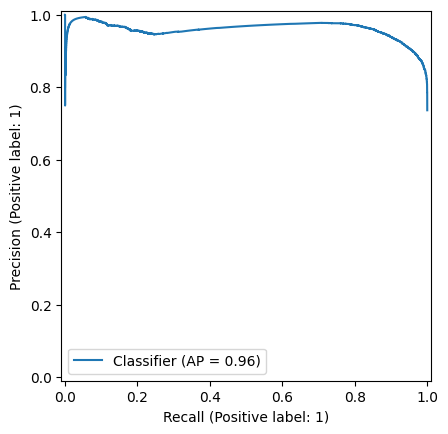

In [27]:
y_score = model.predict_proba(X_val_processed)[:, 1]
PrecisionRecallDisplay.from_predictions(
   y_val, y_score)
plt.show()

## todo: Your understanding on above Precision_Recall Curve

## Get columns whose gradient become 0 from lasso regression

In [21]:
feature_names = np.array(preprocessor.get_feature_names())

if feature_names.shape[0] != X_train_processed.shape[1]:
    raise ValueError(
        f"Feature name count ({feature_names.shape[0]}) does not match "
        f"the number of processed columns ({X_train_processed.shape[1]}); "
        f"the fitted preprocessor and X_train_processed are out of sync."
    )

if "lasso_model" not in dir():
    raise NameError(
        "lasso_model is not defined. Run the Lasso regression cell above first."
    )

lasso_coefs = lasso_model.coef_.ravel()

# Lasso zeroes coefficients out exactly (not just "close to zero"), but we
# use isclose for safety against tiny floating point noise from the solver.
zero_weight_mask = np.isclose(lasso_coefs, 0.0)
kept_features_mask = ~zero_weight_mask

zero_weight_features = feature_names[zero_weight_mask]
kept_feature_names = feature_names[kept_features_mask]

print(
    f"Lasso (L1) shrank {zero_weight_mask.sum()} of {len(feature_names)} "
    f"features to exactly 0:\n"
)
if zero_weight_mask.sum() == 0:
    print("  (none -- every feature kept a non-zero weight)")
else:
    for name, coef in zip(feature_names[zero_weight_mask], lasso_coefs[zero_weight_mask]):
        print(f"  - {name}  (coef={coef:.6f})")

print(f"\n{kept_features_mask.sum()} features remain with non-zero weight.")

Lasso (L1) shrank 2 of 97 features to exactly 0:

  - num__total_tl  (coef=0.000000)
  - num__tot_closed_tl  (coef=-0.000000)

95 features remain with non-zero weight.


## Run Logistic Regression excluding features from Lasso

In [24]:
if kept_features_mask.sum() == 0:
    raise ValueError(
        "All features were shrunk to 0 by Lasso; cannot fit a model with zero features. "
        "Try a smaller C (weaker regularisation) in the Lasso cell above."
    )

X_train_reduced = X_train_processed[:, kept_features_mask]
X_val_reduced = X_val_processed[:, kept_features_mask]
X_test_reduced = X_test_processed[:, kept_features_mask]

reduced_model = LogisticRegression(max_iter=500, solver="lbfgs", random_state=42)
reduced_model.fit(X_train_reduced, y_train)

metrics = evaluate_classification(reduced_model, X_val_reduced, y_val, binary=True)

train_loss_reduced = log_loss(y_train, reduced_model.predict_proba(X_train_reduced))
val_loss_reduced = log_loss(y_val, reduced_model.predict_proba(X_val_reduced))

print(
    f"Reduced-feature model | Train loss: {train_loss_reduced:.4f} | "
    f"Val loss: {val_loss_reduced:.4f}"
)
print(f"Features used: {X_train_reduced.shape[1]} (down from {X_train_processed.shape[1]})")
print(metrics)

              precision    recall  f1-score   support

           0       0.84      0.73      0.78      2030
           1       0.91      0.95      0.93      5670

    accuracy                           0.89      7700
   macro avg       0.87      0.84      0.85      7700
weighted avg       0.89      0.89      0.89      7700

Reduced-feature model | Train loss: 0.2738 | Val loss: 0.2773
Features used: 95 (down from 97)
{'accuracy': 0.8923376623376623, 'f1_macro': 0.8549570380124445, 'precision_macro': 0.8742798137299532, 'recall_macro': 0.8400869670984614, 'precision_weighted': 0.8900123577539027, 'recall_weighted': 0.8923376623376623, 'f1_weighted': 0.8897652939714604, 'confusion_matrix': array([[1481,  549],
       [ 280, 5390]]), 'roc_auc': 0.9317370830835527}


## Binary Logistic Regression with PCA features

In [17]:
pca_df = pd.read_csv("output/results_pca/pca_component_scores.csv")
pca_df.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19',
       'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28',
       'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37',
       'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46',
       'approved_flag', 'approved_flag_binary', 'credit_score', 'split'],
      dtype='object')

In [18]:
pca_df.split.value_counts()

split
train    35935
test      7701
val       7700
Name: count, dtype: int64

In [19]:
pca_reg = pca_df.copy()
pca_reg = pca_reg.drop(columns=['approved_flag', 'approved_flag_binary', 'credit_score'])
y_pca_train = pca_df[pca_df.split=='train']['approved_flag_binary']
y_pca_val = pca_df[pca_df.split=='val']['approved_flag_binary']
y_pca_test = pca_df[pca_df.split=='test']['approved_flag_binary']

In [20]:
pca_train = pca_reg[pca_reg.split == 'train']
pca_val = pca_reg[pca_reg.split == 'val']
pca_test = pca_reg[pca_reg.split == 'test']
pca_train = pca_train.drop(columns=['split'])
pca_val = pca_val.drop(columns=['split'])
pca_test = pca_test.drop(columns=['split'])

In [21]:
model = LogisticRegression(max_iter=500, solver="lbfgs",
        random_state=42)
model.fit(pca_train, y_pca_train)
y_pred = model.predict(pca_val)
y_prob = model.predict_proba(pca_val)[:,1]

In [23]:
evaluate_classification(model, pca_test, y_pca_test, binary=True)

              precision    recall  f1-score   support

           0       0.82      0.66      0.73      2022
           1       0.89      0.95      0.92      5679

    accuracy                           0.87      7701
   macro avg       0.85      0.81      0.83      7701
weighted avg       0.87      0.87      0.87      7701



{'accuracy': 0.873652772367225,
 'f1_macro': 0.8255455780146266,
 'precision_macro': 0.8543474381195231,
 'recall_macro': 0.8060528585976864,
 'precision_weighted': 0.8702805474275452,
 'recall_weighted': 0.873652772367225,
 'f1_weighted': 0.8690490423438681,
 'confusion_matrix': array([[1342,  680],
        [ 293, 5386]]),
 'roc_auc': 0.9181405925905026}

## Below Precision Recall plot shows there is no loss in model performance after using PCA features. Could reduce features to 46.

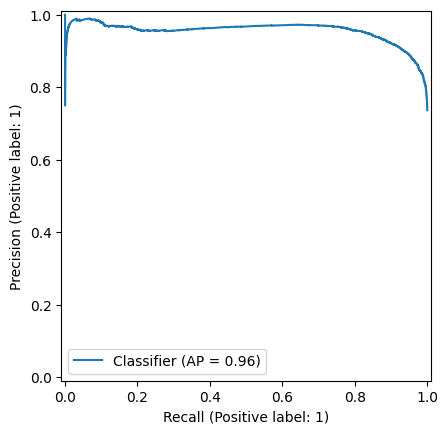

In [24]:
y_score = model.predict_proba(pca_val)[:, 1]
PrecisionRecallDisplay.from_predictions(
   y_pca_val, y_score)
plt.show()